In [39]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
import lime
import lime.lime_tabular

In [40]:
df = pd.read_csv("ResearhData.csv")
print(df.shape)
df.head()

(2541, 13)


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
0,NOSTRESS,-0.030326,-0.030742,0.000124,0.0,0.0,-0.810,0.3750,-1.121333,-0.036966,-0.5,-33.871843,-0.488629
1,NOSTRESS,-0.027412,-0.028501,0.003034,0.0,0.0,-1.320,0.3675,-0.771936,0.317007,-0.5,-33.871843,-0.488629
2,NOSTRESS,-0.027540,-0.028821,0.002604,0.0,0.0,-1.380,0.3625,-0.913694,0.263580,-0.5,-33.871843,-0.488629
3,NOSTRESS,-0.018734,-0.016492,0.004473,0.0,0.0,-2.285,0.4050,-0.272774,0.462842,-0.5,-33.871843,-0.488629
4,NOSTRESS,-0.012041,-0.014570,-0.005277,0.0,0.0,-2.715,0.4125,0.057561,0.002796,-0.5,-33.871843,-0.488629


In [41]:
df['Label'].unique()

array(['NOSTRESS', 'STRESS'], dtype=object)

## Data Description 

In [42]:
df.describe(include='all')

,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
count,2541,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.133460,0.134660,0.011387,0.226682,0.025125,9.303126,-0.317973,-0.110210,0.621465,-1.519776,-31.099023,-0.441252
std,NaN,0.310719,0.314339,0.039412,0.783278,0.105890,14.661003,0.599100,0.877497,1.110321,13.332870,32.091973,4.118833
min,NaN,-1.083348,-1.065445,-0.064407,-4.000000,-0.219829,-29.775000,-2.073750,-11.392412,-7.634984,-43.500000,-99.875000,-18.977173
25%,NaN,0.038008,0.039704,-0.000006,0.000000,0.000000,0.325000,-0.748750,-0.581779,0.045387,-10.000000,-52.300000,-2.154263
50%,NaN,0.085989,0.086309,0.001395,0.000000,0.000000,7.800000,-0.265000,-0.127017,0.250669,-0.500000,-33.871843,-0.488629
75%,NaN,0.157703,0.159619,0.007714,0.000000,0.000000,15.570000,0.067500,0.366051,0.993110,8.000000,-11.863636,1.978926


## Missingness

In [43]:
missing_counts = df.isnull().sum()

missing_counts = missing_counts[missing_counts > 2541/2]

missing_counts.sort_values(ascending=False)

Series([], dtype: int64)

## Low Variability

In [44]:
from sklearn.feature_selection import VarianceThreshold

df_num = df.select_dtypes(include=['number'])

# Set your variance threshold (e.g., 0.01 is a common starting point)
my_threshold = 0.01
selector = VarianceThreshold(threshold=my_threshold)
selector.fit(df_num)

# Get boolean mask of features that pass the threshold
mask = selector.get_support()

# Get list of all column names
all_features = df_num.columns

# Features that were removed (low variance)
low_variability_features = all_features[~mask]

# Show the names of low-variability columns
print("Low variability features (variance < {:.2f}):".format(my_threshold))
print(low_variability_features.tolist())

Low variability features (variance < 0.01):
['EDA_sd_delta']


In [45]:
for col in df.select_dtypes(include='object'):
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"{col} ({top_freq:.1%})")

In [46]:
df.dtypes

Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object

## Sampling 

In [47]:
pd.crosstab(index = df['Label'], columns = "count") 

col_0,count
Label,
NOSTRESS,1229
STRESS,1312


In [48]:
train = df.groupby("Label", group_keys=False).sample(frac=0.75, random_state=1234)
test = df.loc[df.index.difference(train.index)]
train.head()


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
2220,NOSTRESS,-0.091091,-0.091315,0.000187,-2.0,-0.043149,35.41,-0.2400,-0.450977,0.439211,-1.0,-62.000000,-4.964245
850,NOSTRESS,-0.031503,-0.033947,0.009839,0.5,0.041946,57.27,-1.3125,-0.497868,2.271804,10.0,-54.428571,-1.730073
427,NOSTRESS,0.194776,0.194680,-0.000229,0.0,0.000000,-28.80,1.3750,1.841169,0.090760,2.0,-44.550000,-0.622952
1162,NOSTRESS,0.340880,0.340912,0.000109,0.5,0.041793,11.06,-0.5550,-0.509152,0.090518,-19.0,-32.500000,-1.842775
849,NOSTRESS,-0.043683,-0.041794,0.002562,0.0,0.000000,56.23,-1.3225,0.495889,0.220549,8.5,-57.918182,-4.616893


In [49]:
pd.crosstab(index = train['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,922
STRESS,984


In [50]:
pd.crosstab(index = test['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,307
STRESS,328


In [51]:
# filling in number dtypes with median and flagging with missing 
train_o = train.copy()
num_cols = train_o.select_dtypes(include='number').columns

for col in num_cols:
    if train_o[col].isnull().any():
        # Create missing flag column
        train_o[f'{col}_was_missing'] = train_o[col].isnull().astype(int)

        # Impute with median
        median = train_o[col].median()
        train_o[col] = train_o[col].fillna(median)
print(train_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [52]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(train_o.dtypes)


Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object


In [53]:
# creating X and Y and creating dummies for categorical data 
predictors = train_o.drop(columns=['Label'])
predictors = pd.get_dummies(predictors, drop_first=True)
predictors = predictors.astype(float)

X = predictors

y = train_o['Label']



In [54]:
# using Pearson's square to sort data and determine association, 
# Use p-value of 0.002 depending on the data siize
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Separate categorical (dummy) vs. continuous features
continuous_features = [col for col in X.columns if X[col].nunique() > 2]

X_cont = X[continuous_features]




# Fit SelectKBest for Continous Variables
selector = SelectKBest(score_func=f_classif, k='all')  # 'all' keeps all features for scoring
selector.fit(X_cont, y)

# Create a DataFrame with feature names, F-scores, and p-values
scores_cont_df = pd.DataFrame({
    'Feature': X_cont.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
})

# Filter for features with p-value < 0.002
selected_cont_features = scores_cont_df[scores_cont_df['p_value'] < 0.002]['Feature']

# Create a new DataFrame with only those selected columns
X_reduced = X[selected_cont_features.tolist()]

X_reduced.head()


,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,TEMP_median_delta,ACC_vm_sd_delta,HR_bangle_delta
2220,-0.091091,-0.091315,0.000187,-2.0,-0.043149,-0.2400,0.439211,-1.0
850,-0.031503,-0.033947,0.009839,0.5,0.041946,-1.3125,2.271804,10.0
427,0.194776,0.194680,-0.000229,0.0,0.000000,1.3750,0.090760,2.0
1162,0.340880,0.340912,0.000109,0.5,0.041793,-0.5550,0.090518,-19.0
849,-0.043683,-0.041794,0.002562,0.0,0.000000,-1.3225,0.220549,8.5


## XGBoost

/home/appij25/.local/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 1800x1000 with 0 Axes>

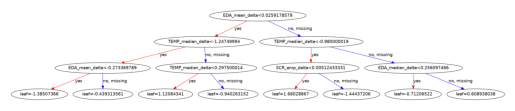

In [55]:
import xgboost as xgb
from xgboost import plot_tree
import matplotlib.pyplot as plt
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})

# Train XGBoost with max_depth=3
xgb_cls = xgb.XGBClassifier(
    random_state=1234,
    max_depth=3,           # only 3 levels
    n_estimators=1,        # single tree for plotting
    learning_rate=1,       # high learning rate since we only use 1 tree
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=1
)
xgb_cls.fit(X_reduced, y)

# Plot the first (and only) tree
plt.figure(figsize=(18,10))
plot_tree(xgb_cls, num_trees=0, rankdir='TB')
plt.show()


## Gradient Search 

In [56]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# --- Step 1: Define classifier ---
xgb_cls = xgb.XGBClassifier(
    random_state=1234,
    use_label_encoder=False,  # suppress warning
    eval_metric='logloss',    # required for binary classification

)

# --- Step 2: Define hyperparameter grid ---
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 1, 5]
}

# --- Step 3: Define cross-validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

# --- Step 4: Define scoring metric ---
scorer = make_scorer(f1_score)  # good for imbalanced data

# --- Step 5: GridSearchCV setup ---
grid_search = GridSearchCV(
    estimator=xgb_cls,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# --- Step 6: Fit on training data ---
grid_search.fit(X_reduced, y)  # X_reduced = training features

# --- Step 7: Best hyperparameters ---
print("Best Hyperparameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# --- Step 8: Best estimator ---
best_xgb = grid_search.best_estimator_


Fitting 5 folds for each of 729 candidates, totalling 3645 fits


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=300, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.0s
[CV

/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=3, n_estimators=300, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=5, n_estimators=500, subsample=0.7; total time=   0.2s
[CV] E

/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best F1 Score: 0.8671060343514991


In [57]:
%%time
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# --- Define the Optuna objective function ---
def objective(trial):
    # Suggest hyperparameters
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int("n_estimators", 100, 800, step=100)
    subsample = trial.suggest_float("subsample", 0.7, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.7, 1.0)
    gamma = trial.suggest_float("gamma", 0, 5)
    
    # Handle imbalanced classes
    scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

    # Define classifier
    xgb_cls = xgb.XGBClassifier(
        random_state=1234,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False
    )

    # Stratified CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
    
    # Evaluate using weighted F1 score (good for Stress imbalance)
    score = cross_val_score(xgb_cls, X_reduced, y, cv=cv, scoring=make_scorer(f1_score))
    return score.mean()  # maximize F1

# --- Run Optuna study ---
sampler = optuna.samplers.TPESampler(seed=1234)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- Results ---
print("Best Parameters:", study.best_params)
print("Best CV F1 Score:", study.best_value)


[I 2026-01-26 11:20:12,969] A new study created in memory with name: no-name-4ea2bd91-49a2-419d-bb40-8db6ac85f588


  0%|          | 0/50 [00:00<?, ?it/s]

/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:13,281] Trial 0 finished with value: 0.8316008709060998 and parameters: {'max_depth': 4, 'learning_rate': 0.0829717191136948, 'n_estimators': 400, 'subsample': 0.9356075751141307, 'colsample_bytree': 0.933992742435641, 'gamma': 1.3629630264132082}. Best is trial 0 with value: 0.8316008709060998.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:13,649] Trial 1 finished with value: 0.8139394979328 and parameters: {'max_depth': 5, 'learning_rate': 0.15291934777093275, 'n_estimators': 800, 'subsample': 0.9627797904226284, 'colsample_bytree': 0.80734518098736, 'gamma': 2.5049756276172936}. Best is trial 0 with value: 0.8316008709060998.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:14,454] Trial 2 finished with value: 0.8598996749768663 and parameters: {'max_depth': 8, 'learning_rate': 0.11291387512427899, 'n_estimators': 300, 'subsample': 0.8683588558196875, 'colsample_bytree': 0.8509249495923429, 'gamma': 0.0688422479534112}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:14,656] Trial 3 finished with value: 0.8483502127907713 and parameters: {'max_depth': 9, 'learning_rate': 0.20126490980313905, 'n_estimators': 300, 'subsample': 0.8846188535300481, 'colsample_bytree': 0.722614372492893, 'gamma': 1.8441200300098726}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:14,930] Trial 4 finished with value: 0.8421979329737951 and parameters: {'max_depth': 10, 'learning_rate': 0.09165675979627692, 'n_estimators': 400, 'subsample': 0.9366190428822236, 'colsample_bytree': 0.7950508366506613, 'gamma': 2.840493263130346}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:15,421] Trial 5 finished with value: 0.8264067659654664 and parameters: {'max_depth': 9, 'learning_rate': 0.044084004208671146, 'n_estimators': 700, 'subsample': 0.7431300473543694, 'colsample_bytree': 0.9112782913355006, 'gamma': 3.522906540947863}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:15,642] Trial 6 finished with value: 0.8389409118524165 and parameters: {'max_depth': 4, 'learning_rate': 0.23234944103497734, 'n_estimators': 400, 'subsample': 0.9727947876917418, 'colsample_bytree': 0.7179427668339555, 'gamma': 0.9214354190690682}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:15,899] Trial 7 finished with value: 0.8000899634785436 and parameters: {'max_depth': 3, 'learning_rate': 0.09928439327131382, 'n_estimators': 500, 'subsample': 0.8599930488996251, 'colsample_bytree': 0.712997218808441, 'gamma': 2.8071654003169892}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:16,117] Trial 8 finished with value: 0.8323939017619704 and parameters: {'max_depth': 5, 'learning_rate': 0.055327748774862504, 'n_estimators': 100, 'subsample': 0.8821581118655454, 'colsample_bytree': 0.8697833929151594, 'gamma': 0.03382030995001395}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:16,431] Trial 9 finished with value: 0.8292912586776364 and parameters: {'max_depth': 7, 'learning_rate': 0.22249287221059869, 'n_estimators': 700, 'subsample': 0.9976244398565084, 'colsample_bytree': 0.9876405286458599, 'gamma': 3.959820676458199}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:16,706] Trial 10 finished with value: 0.8125474647291122 and parameters: {'max_depth': 7, 'learning_rate': 0.014710816127701233, 'n_estimators': 100, 'subsample': 0.7670712241533985, 'colsample_bytree': 0.8134615727250202, 'gamma': 4.739486462136874}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:16,957] Trial 11 finished with value: 0.8574370704799179 and parameters: {'max_depth': 9, 'learning_rate': 0.16023893678380652, 'n_estimators': 200, 'subsample': 0.8077539008846065, 'colsample_bytree': 0.7677871903833087, 'gamma': 1.011498351149041}. Best is trial 2 with value: 0.8598996749768663.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:17,735] Trial 12 finished with value: 0.8640246486305806 and parameters: {'max_depth': 8, 'learning_rate': 0.030548083497381116, 'n_estimators': 200, 'subsample': 0.7891380606552709, 'colsample_bytree': 0.7638931615767105, 'gamma': 0.2844657224797673}. Best is trial 12 with value: 0.8640246486305806.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:18,585] Trial 13 finished with value: 0.8612966260968216 and parameters: {'max_depth': 8, 'learning_rate': 0.02310268732275763, 'n_estimators': 200, 'subsample': 0.799258221697143, 'colsample_bytree': 0.8581003295503009, 'gamma': 0.06504086632926753}. Best is trial 12 with value: 0.8640246486305806.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:19,193] Trial 14 finished with value: 0.8420361635956592 and parameters: {'max_depth': 6, 'learning_rate': 0.018981159792178588, 'n_estimators': 200, 'subsample': 0.7043291486102607, 'colsample_bytree': 0.8869158779532398, 'gamma': 0.5983892077300359}. Best is trial 12 with value: 0.8640246486305806.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:19,695] Trial 15 finished with value: 0.8528627647847993 and parameters: {'max_depth': 8, 'learning_rate': 0.026129771822284507, 'n_estimators': 200, 'subsample': 0.8112244581417898, 'colsample_bytree': 0.7806811346595066, 'gamma': 1.767329048429982}. Best is trial 12 with value: 0.8640246486305806.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:21,390] Trial 16 finished with value: 0.8662605370852233 and parameters: {'max_depth': 8, 'learning_rate': 0.02966776165824622, 'n_estimators': 500, 'subsample': 0.8152099025099594, 'colsample_bytree': 0.7521578704245473, 'gamma': 0.012510771191889702}. Best is trial 16 with value: 0.8662605370852233.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:23,864] Trial 17 finished with value: 0.8692365424466283 and parameters: {'max_depth': 10, 'learning_rate': 0.010330681145425423, 'n_estimators': 600, 'subsample': 0.833067340635824, 'colsample_bytree': 0.7512140986342634, 'gamma': 0.529755635158584}. Best is trial 17 with value: 0.8692365424466283.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:25,077] Trial 18 finished with value: 0.8551940433113518 and parameters: {'max_depth': 10, 'learning_rate': 0.010916707483736757, 'n_estimators': 600, 'subsample': 0.8365416861398431, 'colsample_bytree': 0.737884134881538, 'gamma': 1.6838553708863162}. Best is trial 17 with value: 0.8692365424466283.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:27,044] Trial 19 finished with value: 0.865726416454773 and parameters: {'max_depth': 10, 'learning_rate': 0.011538519992033204, 'n_estimators': 600, 'subsample': 0.8299609969695854, 'colsample_bytree': 0.8275256485103258, 'gamma': 0.7786604300142776}. Best is trial 17 with value: 0.8692365424466283.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:27,502] Trial 20 finished with value: 0.8566254885823298 and parameters: {'max_depth': 9, 'learning_rate': 0.0516192182629004, 'n_estimators': 500, 'subsample': 0.9081248976345291, 'colsample_bytree': 0.7426084454603789, 'gamma': 1.3985970776676169}. Best is trial 17 with value: 0.8692365424466283.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:29,814] Trial 21 finished with value: 0.8674173028655889 and parameters: {'max_depth': 10, 'learning_rate': 0.010165642007671326, 'n_estimators': 600, 'subsample': 0.8356765853152689, 'colsample_bytree': 0.8244830653542943, 'gamma': 0.6537131975360427}. Best is trial 17 with value: 0.8692365424466283.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:31,715] Trial 22 finished with value: 0.8678975386292826 and parameters: {'max_depth': 10, 'learning_rate': 0.016187433056666613, 'n_estimators': 600, 'subsample': 0.7614065168559311, 'colsample_bytree': 0.7579445756572787, 'gamma': 0.5523448631525125}. Best is trial 17 with value: 0.8692365424466283.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:33,415] Trial 23 finished with value: 0.8750733487890298 and parameters: {'max_depth': 10, 'learning_rate': 0.016053326924005268, 'n_estimators': 600, 'subsample': 0.7488201376102107, 'colsample_bytree': 0.7011955930102503, 'gamma': 0.5611560456687918}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:34,709] Trial 24 finished with value: 0.866421268854771 and parameters: {'max_depth': 10, 'learning_rate': 0.015718429108936345, 'n_estimators': 700, 'subsample': 0.7263885976270027, 'colsample_bytree': 0.7104872819815489, 'gamma': 1.091685907861318}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:35,619] Trial 25 finished with value: 0.8506017997695651 and parameters: {'max_depth': 9, 'learning_rate': 0.01518511023241895, 'n_estimators': 800, 'subsample': 0.7674301689163487, 'colsample_bytree': 0.7017588734934995, 'gamma': 2.1333519681531934}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:36,817] Trial 26 finished with value: 0.8678658101426333 and parameters: {'max_depth': 10, 'learning_rate': 0.03828185220696586, 'n_estimators': 600, 'subsample': 0.7698708545242329, 'colsample_bytree': 0.7810355428485934, 'gamma': 0.459226602350074}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:37,833] Trial 27 finished with value: 0.862220336639137 and parameters: {'max_depth': 9, 'learning_rate': 0.01981173629088664, 'n_estimators': 700, 'subsample': 0.7373038684135629, 'colsample_bytree': 0.7375787147215276, 'gamma': 1.2602763601263}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:38,512] Trial 28 finished with value: 0.8417051607228558 and parameters: {'max_depth': 7, 'learning_rate': 0.018890812323287494, 'n_estimators': 600, 'subsample': 0.7068032440947353, 'colsample_bytree': 0.7004525585226571, 'gamma': 2.1846503738910905}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:38,980] Trial 29 finished with value: 0.8505893454684534 and parameters: {'max_depth': 10, 'learning_rate': 0.06751002264635526, 'n_estimators': 500, 'subsample': 0.77943645848646, 'colsample_bytree': 0.7582897319623881, 'gamma': 1.4441997648559655}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:41,012] Trial 30 finished with value: 0.8607289083573626 and parameters: {'max_depth': 6, 'learning_rate': 0.013405466519829028, 'n_estimators': 800, 'subsample': 0.7560455142271508, 'colsample_bytree': 0.9448591151820204, 'gamma': 0.41108894366944904}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:42,298] Trial 31 finished with value: 0.8691910512804217 and parameters: {'max_depth': 10, 'learning_rate': 0.03594265784871946, 'n_estimators': 600, 'subsample': 0.7335761338474718, 'colsample_bytree': 0.7858488969714502, 'gamma': 0.4711701457932795}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:44,460] Trial 32 finished with value: 0.8699916645439938 and parameters: {'max_depth': 10, 'learning_rate': 0.012859176502723045, 'n_estimators': 700, 'subsample': 0.721357167269543, 'colsample_bytree': 0.7924172158171492, 'gamma': 0.6577522801294235}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:46,294] Trial 33 finished with value: 0.864918456225247 and parameters: {'max_depth': 9, 'learning_rate': 0.012542857269767308, 'n_estimators': 700, 'subsample': 0.7239258061577415, 'colsample_bytree': 0.8004482212383429, 'gamma': 0.8624088895999235}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:47,092] Trial 34 finished with value: 0.8603108907004277 and parameters: {'max_depth': 9, 'learning_rate': 0.03359156410604992, 'n_estimators': 700, 'subsample': 0.725082350242732, 'colsample_bytree': 0.7830269056452754, 'gamma': 1.3668106536622646}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:48,899] Trial 35 finished with value: 0.8722152340406133 and parameters: {'max_depth': 10, 'learning_rate': 0.02190534256605068, 'n_estimators': 800, 'subsample': 0.7483319010537994, 'colsample_bytree': 0.7312787514514119, 'gamma': 0.41255440458428316}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:50,890] Trial 36 finished with value: 0.8680781791830224 and parameters: {'max_depth': 10, 'learning_rate': 0.02303823844606364, 'n_estimators': 800, 'subsample': 0.7044578455283105, 'colsample_bytree': 0.7328257080667514, 'gamma': 0.32174571775793515}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:52,592] Trial 37 finished with value: 0.8670648183003085 and parameters: {'max_depth': 9, 'learning_rate': 0.010262578852206595, 'n_estimators': 800, 'subsample': 0.7474404207146662, 'colsample_bytree': 0.723981784441752, 'gamma': 1.0927872536516756}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:54,220] Trial 38 finished with value: 0.8664542549555707 and parameters: {'max_depth': 8, 'learning_rate': 0.012802590622148583, 'n_estimators': 800, 'subsample': 0.786659217887888, 'colsample_bytree': 0.723873354687292, 'gamma': 0.8158737926745876}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:54,660] Trial 39 finished with value: 0.7846461507283274 and parameters: {'max_depth': 3, 'learning_rate': 0.017210560581977768, 'n_estimators': 700, 'subsample': 0.9169873427296062, 'colsample_bytree': 0.7468553453987271, 'gamma': 3.19641642776428}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:55,081] Trial 40 finished with value: 0.8568776322394289 and parameters: {'max_depth': 9, 'learning_rate': 0.2891582280908978, 'n_estimators': 400, 'subsample': 0.8572872470230255, 'colsample_bytree': 0.8345438589110418, 'gamma': 0.2289902444634926}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:20:56,609] Trial 41 finished with value: 0.8640509356949089 and parameters: {'max_depth': 10, 'learning_rate': 0.02322206323713567, 'n_estimators': 700, 'subsample': 0.7423732608858533, 'colsample_bytree': 0.790488653988411, 'gamma': 0.6215883561909239}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:57,707] Trial 42 finished with value: 0.8604649138338537 and parameters: {'max_depth': 10, 'learning_rate': 0.021126012211050052, 'n_estimators': 600, 'subsample': 0.7186638971608983, 'colsample_bytree': 0.771589514313634, 'gamma': 1.1621745466886122}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:20:59,507] Trial 43 finished with value: 0.8665428078818866 and parameters: {'max_depth': 10, 'learning_rate': 0.026779851192195735, 'n_estimators': 500, 'subsample': 0.7369015621848531, 'colsample_bytree': 0.8100155896344646, 'gamma': 0.24124280197413386}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:20:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:21:00,306] Trial 44 finished with value: 0.8653782258119325 and parameters: {'max_depth': 9, 'learning_rate': 0.04486274895736615, 'n_estimators': 700, 'subsample': 0.752441699607714, 'colsample_bytree': 0.7284935755741192, 'gamma': 0.8390008487215476}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:21:01,409] Trial 45 finished with value: 0.8558657780796661 and parameters: {'max_depth': 10, 'learning_rate': 0.013208846192366544, 'n_estimators': 600, 'subsample': 0.7188608055963396, 'colsample_bytree': 0.7152566958097119, 'gamma': 1.5749854989994765}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:21:01,845] Trial 46 finished with value: 0.8005857160070298 and parameters: {'max_depth': 5, 'learning_rate': 0.038285988770646005, 'n_estimators': 800, 'subsample': 0.8867160394705089, 'colsample_bytree': 0.7695682247097999, 'gamma': 4.830426533178038}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:21:02,652] Trial 47 finished with value: 0.8464844069730019 and parameters: {'max_depth': 9, 'learning_rate': 0.01722719365429312, 'n_estimators': 500, 'subsample': 0.9450558030558024, 'colsample_bytree': 0.8009384956195047, 'gamma': 2.0215603366454356}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/tr

[I 2026-01-26 11:21:03,306] Trial 48 finished with value: 0.8259560978202878 and parameters: {'max_depth': 9, 'learning_rate': 0.0148061140629418, 'n_estimators': 700, 'subsample': 0.7778550312667085, 'colsample_bytree': 0.749618176361755, 'gamma': 3.757155382647372}. Best is trial 23 with value: 0.8750733487890298.


/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/appij25/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:21:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-26 11:21:03,541] Trial 49 finished with value: 0.812266884079141 and parameters: {'max_depth': 10, 'learning_rate': 0.12322191224563903, 'n_estimators': 400, 'subsample': 0.7314126878928622, 'colsample_bytree': 0.7106704645324114, 'gamma': 4.46694041360665}. Best is trial 23 with value: 0.8750733487890298.
Best Parameters: {'max_depth': 10, 'learning_rate': 0.016053326924005268, 'n_estimators': 600, 'subsample': 0.7488201376102107, 'colsample_bytree': 0.7011955930102503, 'gamma': 0.5611560456687918}
Best CV F1 Score: 0.8750733487890298
CPU times: user 48 s, sys: 2.5 s, total: 50.5 s
Wall time: 50.6 s


#Best Hyperparameters: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best F1 Score: 0.8671169931020305


{'max_depth': 9, 'learning_rate': 0.043328089568422205, 'n_estimators': 200, 'subsample': 0.8056440758823522, 'colsample_bytree': 0.7446313367857482, 'gamma': 0.9759540842292201}. Best is trial 12 with value: 0.8660672604292248.

In [58]:
#  Train XGBoost with Optuna-best hyperparameters
# --------------------------
best_params = {
    "max_depth": 9,
    "learning_rate": 0.043328089568422205,
    "n_estimators": 200,
    "subsample": 0.8056440758823522,
    "colsample_bytree": 0.7446313367857482,
    "gamma": 0.9759540842292201,
    "random_state": 1234,
    "eval_metric": "logloss",
}

xgb_cls2 = xgb.XGBClassifier(**best_params)
xgb_cls2.fit(X_reduced, y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7446313367857482
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


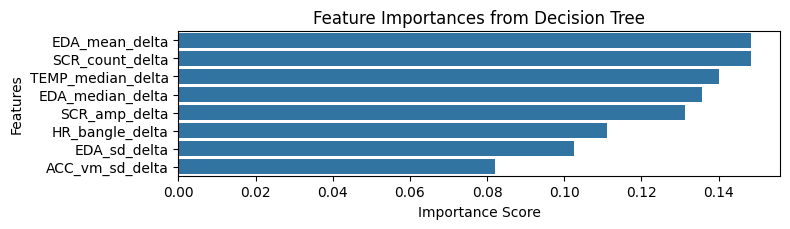

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from trained tree
importances = xgb_cls2.feature_importances_

# Create a Series with feature names from X_selected
feature_importances = pd.Series(importances, index=X_reduced.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, len(sorted_importances) * 0.3))  # dynamic height
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title("Feature Importances from Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [60]:
# --- Predict probabilities for the training set ---
train_o['pred_prob'] = xgb_cls2.predict_proba(X_reduced)[:, 1]  # probability of class 1 (Stress)

# Optional: preview
train_o[['pred_prob']].head()

,pred_prob
2220,0.391332
850,0.182097
427,0.105071
1162,0.133615
849,0.341551


In [61]:
from sklearn.metrics import roc_auc_score

# --- Ensure we have predicted probabilities ---
# Already stored in train_o['pred_prob']
train_o['p_hat'] = train_o['pred_prob']  # probability of Stress = 1

# --- Compute ROC-AUC (C-statistic) ---
auc = roc_auc_score(train_o['Label'], train_o['p_hat'])
print("C-statistic (AUC):", auc)

# --- Compute Somer's D ---
somer_d = 2 * auc - 1
print("Somer's D:", somer_d)


C-statistic (AUC): 0.9955734264500996
Somer's D: 0.9911468529001992


In [62]:
import pandas as pd

# --- Convert predicted probabilities to class labels ---
# Use 0.5 cutoff; you can also replace 0.5 with best_threshold if desired
train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x >0.62375 else 0)

# --- Create confusion matrix ---
conf_matrix = pd.crosstab(train_o['Label'], train_o['pred'],
                          rownames=['Actual'], colnames=['Predicted'])

print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 Predicted    0    1
Actual             
NOSTRESS   910   12
STRESS      87  897


In [63]:
from sklearn.metrics import roc_curve
import pandas as pd

# --- Ensure proper data types ---
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})


y_true = y.astype(int)

y_score = train_o['p_hat'].astype(float)

# --- Check for both classes ---
if len(set(y_true)) < 2:
    raise ValueError("y_true has only one class. Need both positive and negative samples.")

# --- Compute ROC curve ---
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# --- Compute Youden's J statistic ---
youden = pd.DataFrame({
    'TPR': tpr,
    'FPR': fpr,
    'Cut-off': thresholds,
    'Youden': tpr - fpr
})

# --- Sort by Youden's J ---
youden = youden.sort_values(by='Youden', ascending=False).reset_index(drop=True)

# --- Best cutoff ---
best_threshold = youden.loc[0, 'Cut-off']
print("Best threshold (Youden's J):", best_threshold)

# Optional: show top 5 thresholds
youden.head()


Best threshold (Youden's J): 0.43665069341659546


,TPR,FPR,Cut-off,Youden
0,0.970528,0.034707,0.436651,0.935821
1,0.962398,0.027115,0.464936,0.935283
2,0.964431,0.029284,0.454057,0.935147
3,0.968496,0.033623,0.441516,0.934873
4,0.968496,0.034707,0.437212,0.933789


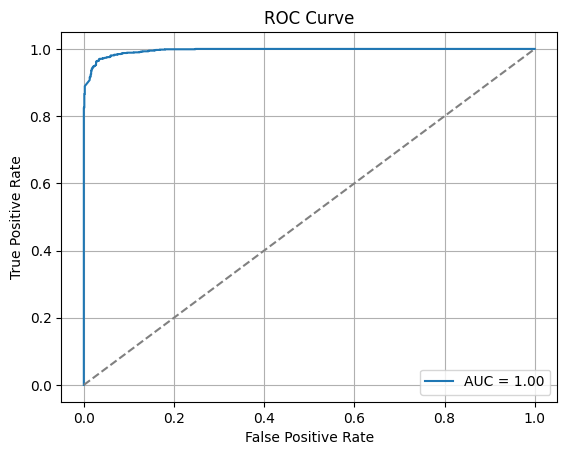

In [64]:
# Roc Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(y, train_o['pred_prob'])

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

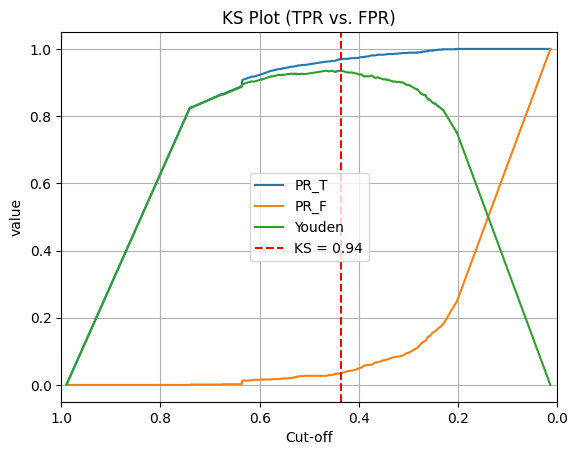

In [65]:
# KS plot 
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y, train_o['pred_prob'])

# Create the Youden DataFrame
youden = pd.DataFrame({
    'Cut-off': thresholds,
    'TPR': tpr,
    'FPR': fpr,
    'Youden': tpr - fpr
})

# Sort by Cut-off and rename
youden = youden.sort_values(by='Cut-off', ascending=True)

ks_stat = youden.rename(columns={'TPR': 'PR_T', 'FPR': 'PR_F'})
ks_stat = ks_stat.melt(id_vars='Cut-off', var_name='PR', value_name='value')

ks_val = (youden['TPR'] - youden['FPR']).max()
ks_cutoff = youden.loc[(youden['TPR'] - youden['FPR']).idxmax(), 'Cut-off']

# Plot
sns.lineplot(x='Cut-off', y='value', hue='PR', data=ks_stat)
plt.xlim(1, 0)
plt.title("KS Plot (TPR vs. FPR)")
plt.grid(True)
plt.axvline(x=ks_cutoff, linestyle='--', color='red', label=f'KS = {ks_val:.2f}')
plt.legend()
plt.show()


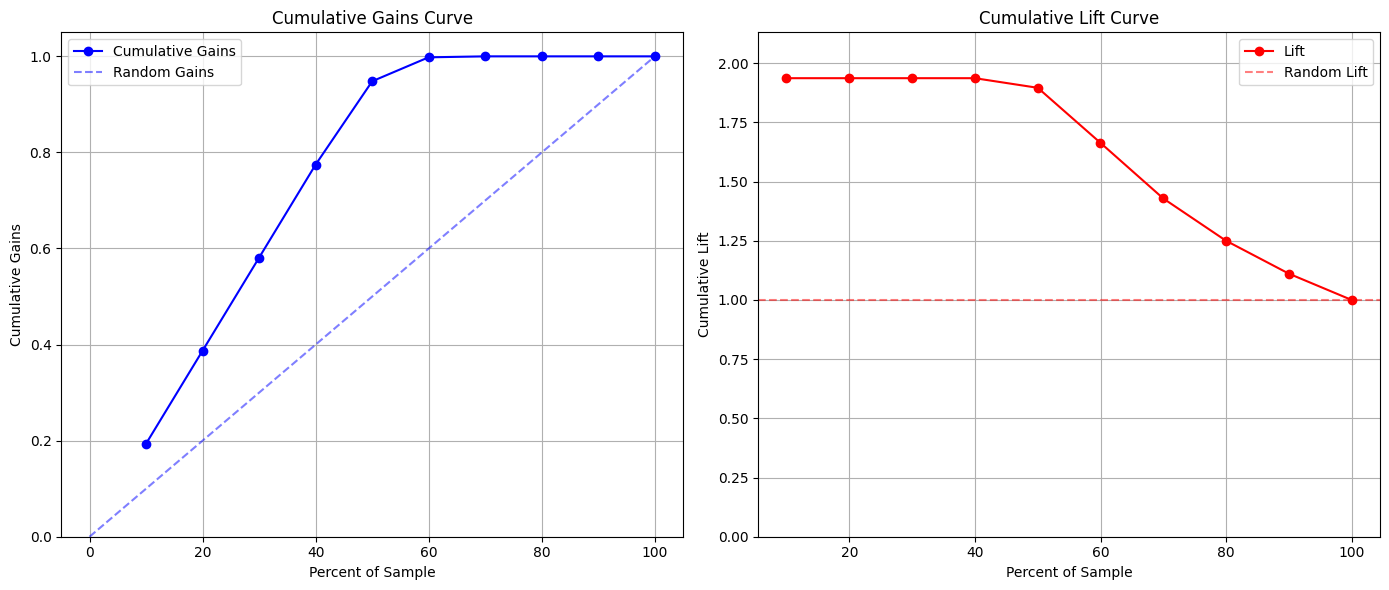

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_and_gains(y_true, y_proba, n_bins=10):
    """
    Plot Lift and Cumulative Gains curves.

    Parameters:
    - y_true: array-like, true binary labels (0/1)
    - y_proba: array-like, predicted probabilities for the positive class
    - n_bins: number of bins/deciles to split data
    """
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    
    # Sort descending by predicted probability
    df = df.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    
    # Cumulative totals
    df['cum_total'] = np.arange(1, len(df) + 1)
    df['cum_positives'] = df['y_true'].cumsum()
    
    total_positives = df['y_true'].sum()
    total_samples = len(df)
    
    # Cumulative Gains: % positives captured vs % samples
    df['cum_gains'] = df['cum_positives'] / total_positives
    
    # Lift: (cumulative gains) / (cumulative % of sample)
    df['cum_lift'] = df['cum_gains'] / (df['cum_total'] / total_samples)
    
    # Sample points for plotting (deciles)
    cutoffs = np.linspace(0, total_samples, n_bins + 1, dtype=int)[1:]  # skip 0
    plot_points = df.loc[cutoffs - 1, ['cum_total', 'cum_gains', 'cum_lift']].copy()
    plot_points['percent_samples'] = plot_points['cum_total'] / total_samples * 100
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Cumulative Gains Curve
    axes[0].plot(plot_points['percent_samples'], plot_points['cum_gains'], marker='o', color='blue', label='Cumulative Gains')
    axes[0].plot([0, 100], [0, 1], linestyle='--', color='blue', alpha=0.5, label='Random Gains')
    axes[0].set_xlabel('Percent of Sample')
    axes[0].set_ylabel('Cumulative Gains')
    axes[0].set_title('Cumulative Gains Curve')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True)
    axes[0].legend()
    
    # Lift Curve
    axes[1].plot(plot_points['percent_samples'], plot_points['cum_lift'], marker='o', color='red', label='Lift')
    axes[1].axhline(1, linestyle='--', color='red', alpha=0.5, label='Random Lift')
    axes[1].set_xlabel('Percent of Sample')
    axes[1].set_ylabel('Cumulative Lift')
    axes[1].set_title('Cumulative Lift Curve')
    axes[1].set_ylim(0, plot_points['cum_lift'].max() * 1.1)
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Example usage:
plot_lift_and_gains(y, train_o['p_hat'])


## Testing 

## Test data Transformation

In [69]:
test_o= test.copy()
num_cols_test = test_o.select_dtypes(include='number').columns

for col in num_cols_test:
    if test_o[col].isnull().any():
        # Create missing flag column
        test_o[f'{col}_was_missing'] = test_o[col].isnull().astype(int)

        # Impute with median
        median = test_o[col].median()
        test_o[col] = test_o[col].fillna(median)
print(test_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [70]:
predictors_test = test_o.drop(columns=['Label'])
predictors_test = pd.get_dummies(predictors_test, drop_first=True)
predictors_test = predictors_test.astype(float)

train_columns = X_reduced.columns 

# Add missing columns in test set
for col in train_columns:
    if col not in predictors_test.columns:
        predictors_test[col] = 0

# Remove extra columns not in training
predictors_test = predictors_test[train_columns]

# Now X_test matches X_train exactly
X_test = predictors_test
y_test = test_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})
X_test.head()




,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,TEMP_median_delta,ACC_vm_sd_delta,HR_bangle_delta
3,-0.018734,-0.016492,0.004473,0.0,0.0,0.4050,0.462842,-0.5
5,-0.015467,-0.016652,0.001588,0.0,0.0,0.4200,-0.028379,-0.5
10,-0.014058,-0.013610,0.000711,0.0,0.0,0.4450,0.067591,-0.5
12,-0.013642,-0.014090,-0.000039,0.0,0.0,0.4075,0.033248,-0.5
15,-0.013418,-0.012809,-0.001220,0.0,0.0,0.4400,-0.393227,-0.5


In [71]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score, confusion_matrix, classification_report
)
import pandas as pd

def evaluate_classification(model, X, y, model_name, threshold):
    """
    Compute classification metrics for a given model and threshold.
    
    Parameters:
    - model: fitted model with predict_proba
    - X: features
    - y: true binary labels
    - model_name: string label for output
    - threshold: probability cutoff for binary prediction
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Convert probabilities to binary predictions using threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Compute metrics
    accuracy = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    # Confusion matrix and classification report
    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, digits=4)
    
    # Display results
    print(f"\n====== {model_name} CLASSIFICATION PERFORMANCE ======")
    print(f"Threshold: {threshold:.6f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(report)
    
    # Return metrics as dictionary for further analysis
    metrics_dict = {
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'ROC-AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ConfusionMatrix': cm,
        'ClassificationReport': report
    }
    
    return metrics_dict


In [72]:
metrics_XGboost  = evaluate_classification(xgb_cls2, X_test, y_test, "XGBooost", threshold=0.43665069341659546)



====== XGBooost CLASSIFICATION PERFORMANCE ======
Threshold: 0.436651
Accuracy : 0.8331
ROC-AUC  : 0.9163
Precision: 0.8405
Recall   : 0.8354
F1 Score : 0.8379

Confusion Matrix:
[[255  52]
 [ 54 274]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8252    0.8306    0.8279       307
           1     0.8405    0.8354    0.8379       328

    accuracy                         0.8331       635
   macro avg     0.8329    0.8330    0.8329       635
weighted avg     0.8331    0.8331    0.8331       635

[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=7, 